In [2]:
import numpy as np
from a5py import Ascot
import matplotlib.pyplot as plt
import unyt
import matplotlib.colors as colors

ERROR:2026-04-24 05:41:53,089:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/pscratch/sd/m/mpatel26/conda_backup/.conda/envs/ascot-develop-mp/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/pscratch/sd/m/mpatel26/conda_backup/.conda/envs/ascot-develop-mp/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/pscratch/sd/m/mpatel26/conda_backup/.conda/envs/ascot-develop-mp/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [3]:
input_dir = "/pscratch/sd/m/mpatel26/ascot_h5s/convergence_studies/"  
lcfs = Ascot(input_dir + "G1600-free-reopt_I_lcfs-wall_1000k-mrk_biot-bfield_FLR-mode_FPP-power_03142026.h5")
new_wall10cm = Ascot(input_dir+ "G1600-free-reopt_I_10cm-wall_1000k-mrk_biot-bfield_p01cellarea_FLR-mode_decay-profile_04082026.h5")
new_wall30cm = Ascot(input_dir+ "G1600-free-reopt_I_30cm-wall_1000k-mrk_biot-bfield_p01cellarea_FLR-mode_decay-profile_04082026.h5")
new_wall20cm = Ascot(input_dir+ "G1600-free-reopt_I_20cm-newwall_100k-mrk_biot-bfield_p01cellarea_GC-mode_decay-profile_alpha-power_04212026.h5")
firstwall = Ascot(input_dir + "G1600-free-reopt_I_divertorwall_1000k-mrk_biot-bfield_p01cellarea_FLR-mode_decay-profile_04262026.h5")
divertorwall = Ascot(input_dir + "G1600-engineeringwall-withtargets-200kmrk-gc-biot-decay-04292026.h5")

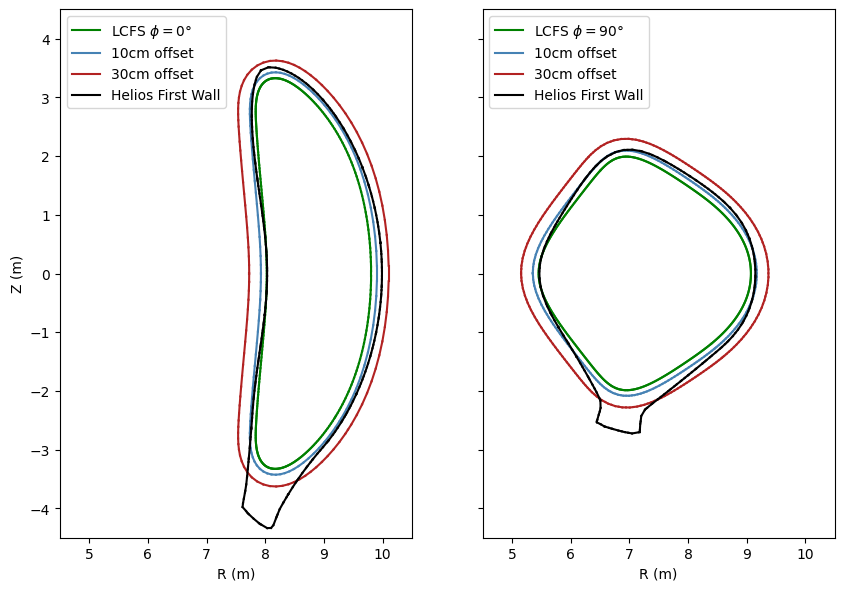

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True)

lcfs.input_plotwallcontour(phi = unyt.unyt_quantity(0, 'degree'), axes = ax1, color="green", label= r"LCFS $\phi=0\degree$")
#lcfs.input_plotwallcontour(phi = unyt.unyt_quantity(45, 'degree'), axes = ax1, color="green", label="45 deg - LCFS")
lcfs.input_plotwallcontour(phi = unyt.unyt_quantity(90, 'degree'), axes = ax2, color="green", label= r"LCFS $\phi=90\degree$")
#lcfs.input_plotwallcontour(phi = unyt.unyt_quantity(135, 'degree'), axes = ax1, color="green", label="135 deg - LCFS")

new_wall10cm.input_plotwallcontour(phi = unyt.unyt_quantity(0, 'degree'), axes = ax1, color="steelblue", label="10cm offset")
#new_wall10cm.input_plotwallcontour(phi = unyt.unyt_quantity(45, 'degree'), axes = ax1, color="steelblue", label="45 deg - 10cm offset")
new_wall10cm.input_plotwallcontour(phi = unyt.unyt_quantity(90, 'degree'), axes = ax2, color="steelblue", label="10cm offset")
#new_wall10cm.input_plotwallcontour(phi = unyt.unyt_quantity(135, 'degree'), axes = ax1, color="steelblue", label="135 deg - 10cm offset")

new_wall30cm.input_plotwallcontour(phi = unyt.unyt_quantity(0, 'degree'), axes = ax1, color="firebrick", label="30cm offset")
#new_wall30cm.input_plotwallcontour(phi = unyt.unyt_quantity(45, 'degree'), axes = ax1, color="red", label="45 deg - 30cm offset")
new_wall30cm.input_plotwallcontour(phi = unyt.unyt_quantity(90, 'degree'), axes = ax2, color="firebrick", label="30cm offset")
#new_wall30cm.input_plotwallcontour(phi = unyt.unyt_quantity(135, 'degree'), axes = ax1, color="red", label="135 deg - 30cm offset")

firstwall.input_plotwallcontour(phi = unyt.unyt_quantity(0, 'degree'), axes = ax1, color="black", label="Engineering Wall")
#firstwall.input_plotwallcontour(phi = unyt.unyt_quantity(45, 'degree'), axes = ax1, color="purple", label="45 deg - 20cm offset")
firstwall.input_plotwallcontour(phi = unyt.unyt_quantity(90, 'degree'), axes = ax2, color="black", label="Engineering Wall")
#firstwall.input_plotwallcontour(phi = unyt.unyt_quantity(135, 'degree'), axes = ax1, color="purple", label="135 deg - 20cm offset")

divertorwall.input_plotwallcontour(phi = unyt.unyt_quantity(0, 'degree'), axes = ax1, color="black", label="Divertor Target")
#firstwall.input_plotwallcontour(phi = unyt.unyt_quantity(45, 'degree'), axes = ax1, color="purple", label="45 deg - 20cm offset")
divertorwall.input_plotwallcontour(phi = unyt.unyt_quantity(90, 'degree'), axes = ax2, color="black", label="Divertor Target")
#firstwall.input_plotwallcontour(phi = unyt.unyt_quantity(135, 'degree'), axes = ax1, color="purple", label="135 deg - 20cm offset")

#fig.set_title("G-1600-free-reopt_I Wall Contours")
ax1.set_xlabel("R (m)")
ax1.set_ylabel("Z (m)")
ax1.set_xlim(4.5,10.5)
ax1.set_ylim(-4.5,4.5)
ax1.legend(loc="upper left")
ax2.set_xlabel("R (m)")
ax2.set_ylabel("")
ax2.set_xlim(4.5,10.5)
ax2.set_ylim(-4.5,4.5)
ax2.legend(loc="upper left")


In [5]:
mesh = new_wall10cm.data.active.getwall_3dmesh()
mesh.save("G1600_10cm_Biot_expdecay.vtk")

divertormesh = firstwall.data.active.getwall_3dmesh()
divertormesh.save("G1600_divertor_wall.vtk")